In [1]:
# =========================================
# 1️⃣ INSTALL + IMPORTS
# =========================================
!pip install neo4j

import json
from neo4j import GraphDatabase

# =========================================
# 2️⃣ CONNECT TO NEO4J
# =========================================
# 👉 Update these if needed
URI = "neo4j+s://93d98142.databases.neo4j.io"   # or Neo4j Aura URI
USER = "93d98142"
PASSWORD = "LNLuv1ua3_jCsjnlwxo2gPTlx0k_7yVaWC8bHs-SHEA"

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

# =========================================
# 3️⃣ LOAD TRIPLETS
# =========================================
with open("/content/final_triplets_level2.json") as f:
    triplets = json.load(f)

print(f"✅ Loaded {len(triplets)} triplets")

# =========================================
# 4️⃣ CLEAN TRIPLETS (REMOVE SELF-LOOPS ONLY)
# =========================================
clean_triplets = []
self_loops = []

for t in triplets:
    e1 = t["entity1"].strip()
    e2 = t["entity2"].strip()

    if e1.lower() == e2.lower():
        self_loops.append(t)
        continue

    clean_triplets.append({
        "entity1": e1,
        "entity2": e2,
        "relation": t["relation"],
        "entity1_type": t["entity1_type"],
        "entity2_type": t["entity2_type"]
    })

print(f"❌ Removed self-loops: {len(self_loops)}")
print(f"✅ Remaining triplets: {len(clean_triplets)}")

triplets = clean_triplets

# =========================================
# 5️⃣ CLEAR EXISTING GRAPH (OPTIONAL BUT RECOMMENDED)
# =========================================
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")

print("🧹 Database cleared")

# =========================================
# 6️⃣ INSERT GRAPH INTO NEO4J
# =========================================
def insert_triplet(tx, e1, e2, rel, type1, type2):
    query = """
    MERGE (a:Entity {name: $e1})
    SET a.type = $type1

    MERGE (b:Entity {name: $e2})
    SET b.type = $type2

    MERGE (a)-[r:RELATION {type: $rel}]->(b)
    """
    tx.run(query, e1=e1, e2=e2, rel=rel, type1=type1, type2=type2)


with driver.session() as session:
    for t in triplets:
        session.execute_write(
            insert_triplet,
            t["entity1"],
            t["entity2"],
            t["relation"],
            t["entity1_type"],
            t["entity2_type"]
        )

print("🚀 Graph successfully created in Neo4j!")

# =========================================
# 7️⃣ CLOSE DRIVER
# =========================================
driver.close()

print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 3.2 MB/s eta 0:00:00
✅ Loaded 75 triplets
❌ Removed self-loops: 0
✅ Remaining triplets: 75
🧹 Database cleared
🚀 Graph successfully created in Neo4j!
✅ Done!


✅ Graph → Nodes: 7, Edges: 5


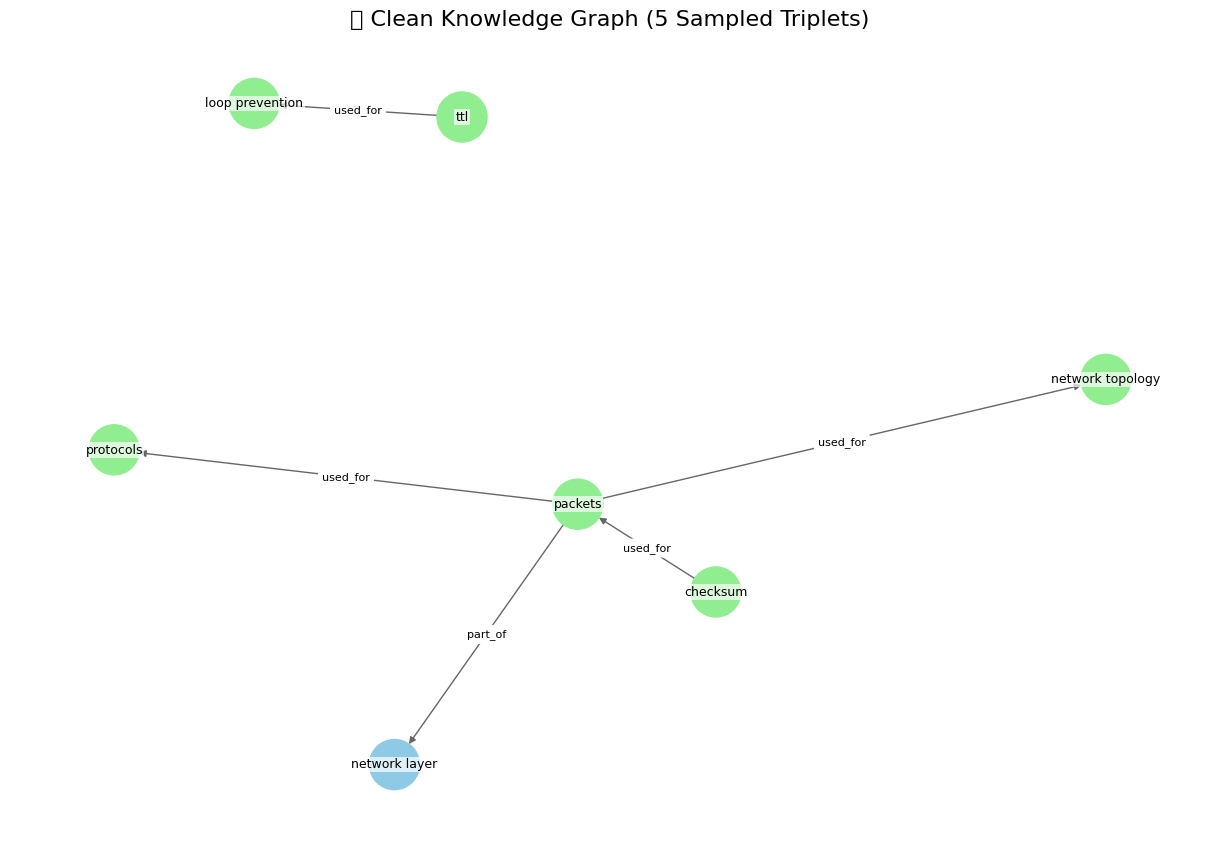

In [4]:
# =========================================
# 🚀 CLEAN NEO4J GRAPH VISUALIZATION
# (5 Sampled Triplets + No 'no_relation')
# =========================================

import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase

# =========================================
# 1️⃣ CONNECT TO NEO4J
# =========================================
URI = "neo4j+s://93d98142.databases.neo4j.io"
USER = "93d98142"
PASSWORD = "LNLuv1ua3_jCsjnlwxo2gPTlx0k_7yVaWC8bHs-SHEA"

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

# =========================================
# 2️⃣ FETCH GRAPH (ONLY 5 SAMPLES)
# =========================================
def fetch_graph(tx):
    query = """
    MATCH (a)-[r]->(b)
    WHERE r.type <> 'no_relation'
    RETURN a.name AS source,
           b.name AS target,
           r.type AS rel,
           a.type AS type1,
           b.type AS type2
    LIMIT 5
    """
    return list(tx.run(query))

with driver.session() as session:
    results = session.execute_read(fetch_graph)

# =========================================
# 3️⃣ BUILD GRAPH
# =========================================
G = nx.DiGraph()

for record in results:
    G.add_node(record["source"], label=record["type1"])
    G.add_node(record["target"], label=record["type2"])
    G.add_edge(
        record["source"],
        record["target"],
        relation=record["rel"]
    )

print(f"✅ Graph → Nodes: {len(G.nodes())}, Edges: {len(G.edges())}")

# =========================================
# 4️⃣ COLOR MAP
# =========================================
color_map = {
    "TOPIC": "#8ecae6",
    "CONCEPT": "#90ee90",
    "METHOD": "#f4a261",
    "ALGORITHM": "#ffafcc",
    "OTHER": "#d3d3d3"
}

node_colors = [
    color_map.get(G.nodes[n].get("label", "OTHER"), "#d3d3d3")
    for n in G.nodes()
]

# =========================================
# 5️⃣ LAYOUT
# =========================================
pos = nx.spring_layout(
    G,
    k=2.5,
    iterations=200,
    seed=42
)

# =========================================
# 6️⃣ DRAW GRAPH
# =========================================
plt.figure(figsize=(12, 8))

nx.draw(
    G, pos,
    with_labels=False,
    node_color=node_colors,
    node_size=1300,
    edge_color="#666",
    arrows=True
)

# =========================================
# 7️⃣ NODE LABELS
# =========================================
for node, (x, y) in pos.items():
    plt.text(
        x, y,
        node,
        fontsize=9,
        ha='center',
        va='center',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='none',
            pad=1
        )
    )

# =========================================
# 8️⃣ EDGE LABELS
# =========================================
edge_labels = nx.get_edge_attributes(G, 'relation')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.5,
    rotate=False
)

# =========================================
# FINAL OUTPUT
# =========================================
plt.title("✨ Clean Knowledge Graph (5 Sampled Triplets)", fontsize=16)
plt.axis("off")
plt.show()

# =========================================
# CLOSE DRIVER
# =========================================
driver.close()

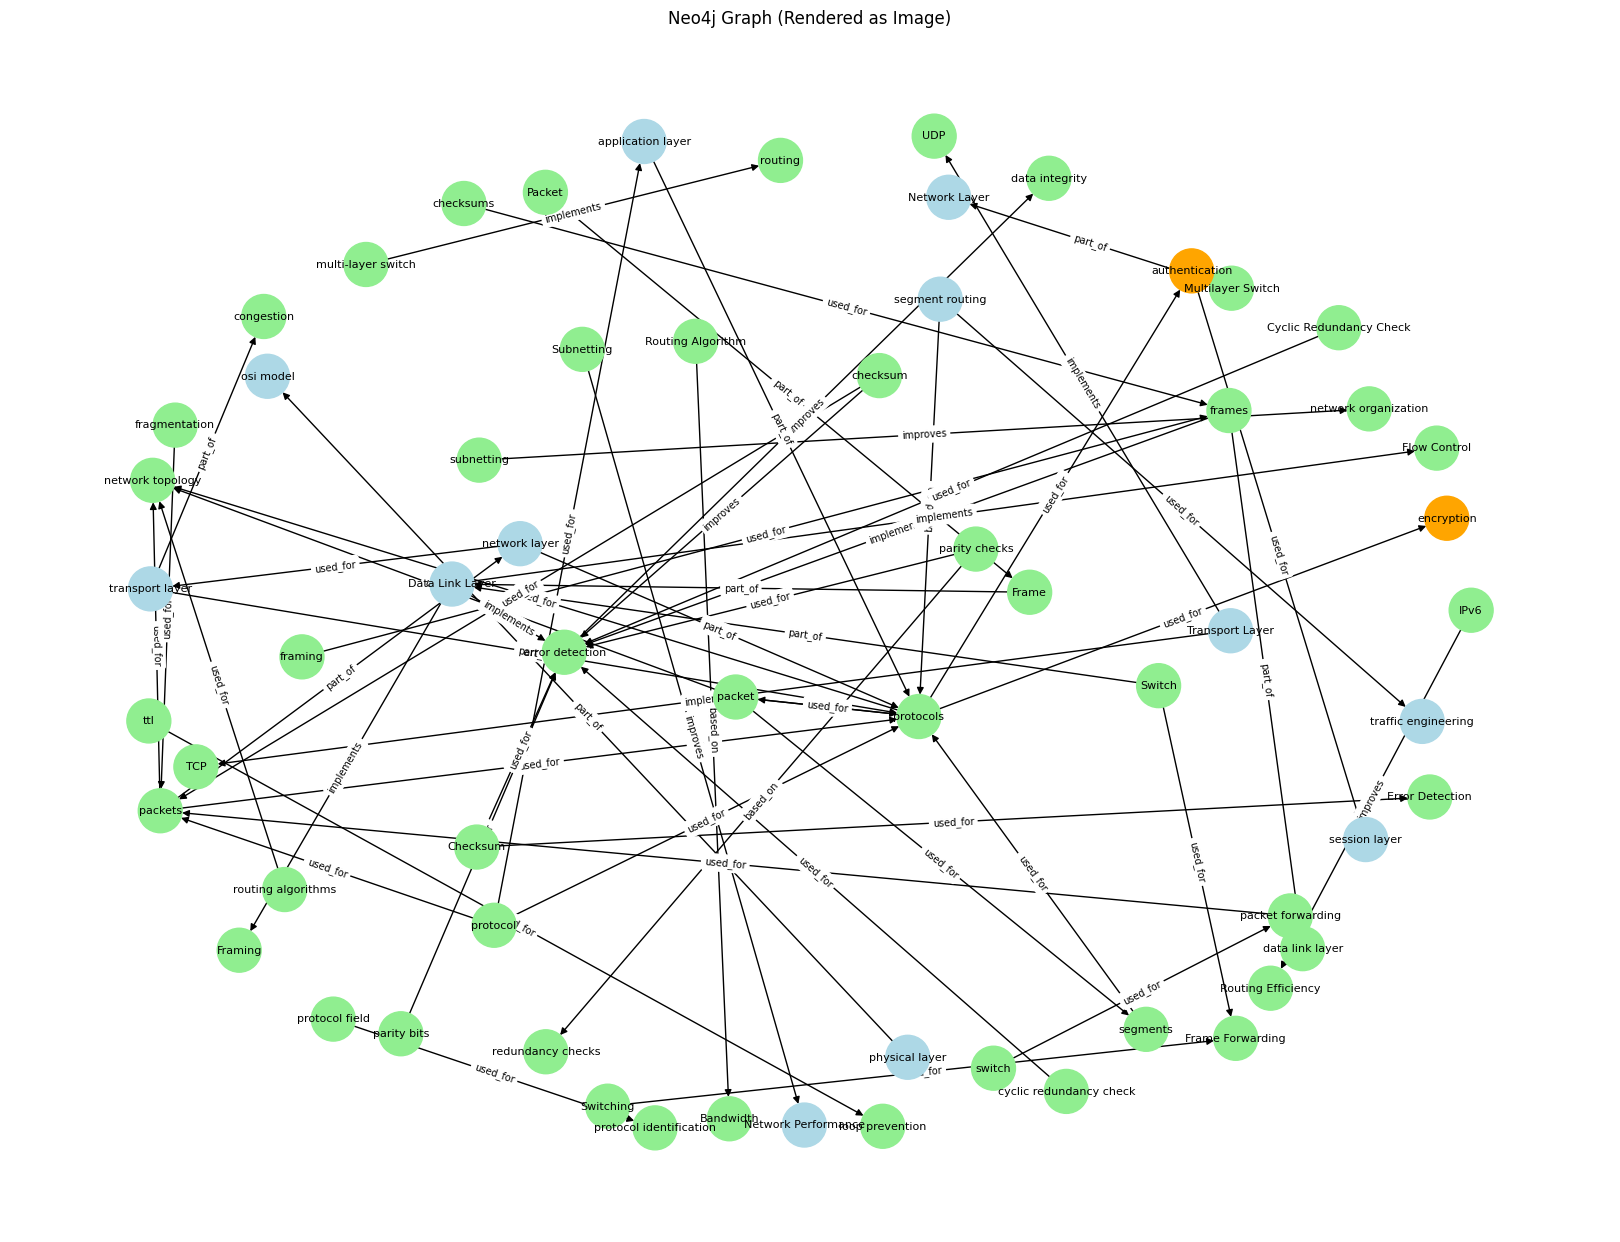

In [5]:
# =========================================
# VISUALIZE NEO4J GRAPH AS IMAGE
# =========================================
import networkx as nx
import matplotlib.pyplot as plt

# Reconnect
from neo4j import GraphDatabase
driver = GraphDatabase.driver("neo4j+s://93d98142.databases.neo4j.io", auth=("93d98142", "LNLuv1ua3_jCsjnlwxo2gPTlx0k_7yVaWC8bHs-SHEA"))

# Fetch graph from Neo4j
def fetch_graph(tx):
    query = """
    MATCH (a)-[r]->(b)
    RETURN a.name AS source, b.name AS target, r.type AS rel,
           a.type AS type1, b.type AS type2
    LIMIT 200
    """
    return list(tx.run(query))

with driver.session() as session:
    results = session.execute_read(fetch_graph)

# Build NetworkX graph (for plotting only)
G = nx.DiGraph()

for record in results:
    G.add_node(record["source"], label=record["type1"])
    G.add_node(record["target"], label=record["type2"])
    G.add_edge(record["source"], record["target"], relation=record["rel"])

# Color map
color_map = {
    "TOPIC": "lightblue",
    "CONCEPT": "lightgreen",
    "METHOD": "orange",
    "ALGORITHM": "pink",
    "OTHER": "gray"
}

node_colors = [
    color_map.get(G.nodes[n].get("label", "OTHER"), "gray")
    for n in G.nodes()
]

# Layout
pos = nx.spring_layout(G, k=2, iterations=100)

# Draw
plt.figure(figsize=(16, 12))

nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1000,
    font_size=8,
    arrows=True
)

# Edge labels
edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Neo4j Graph (Rendered as Image)")
plt.axis("off")
plt.show()